In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import calendar
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates
from binance import Client

/root/miniconda3/envs/finance/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [4]:
client = Client()
klines = np.array(client.get_historical_klines("ETHUSDT", Client.KLINE_INTERVAL_15MINUTE, "1 Jan, 2021"))
sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime', 
                                                                    'open', 
                                                                    'high', 
                                                                    'low', 
                                                                    'close', 
                                                                    'volume', 
                                                                    'close time', 
                                                                    'quote asset volume, number of trades', 
                                                                    'number of trades',
                                                                    'taker buy base asset volume', 
                                                                    'taker buy quote asset volume', 
                                                                    'ignore'])
sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
sample.set_index('datetime', inplace=True)
sample = sample[['open', 'high', 'low', 'close', 'volume']]

sample.describe()

,open,high,low,close,volume
count,28471.000000,28471.000000,28471.000000,28471.000000,28471.000000
mean,2436.080590,2446.126485,2425.616402,2436.197388,10249.911771
std,822.053816,824.265443,819.745421,822.054838,10308.383367
min,715.980000,720.830000,714.290000,715.800000,0.000000
25%,1800.360000,1806.660000,1794.055000,1800.400000,4355.682685
50%,2306.600000,2317.250000,2294.210000,2306.510000,7147.303550
75%,3162.650000,3172.990000,3150.005000,3162.765000,12234.731150
max,4357.890000,4375.000000,4324.010000,4358.740000,207188.891380


In [5]:
sample['number'] = sample.index.map(mdates.date2num)
sample['rtn'] = sample['close'].pct_change()
sample['acc_rtn'] = (1. + sample['rtn']).cumprod()
sample.dropna(inplace=True)
sample.describe()
print(len(sample))

28470


In [6]:
# preprocess
sample['momentum'] = (sample['close'] - sample['close'].shift(10))/sample['close'].shift(10)
sample['WilliamsPR'] = -1.*(sample['high'].rolling(14).max() - sample['close'])/(sample['high'].rolling(14).max() - sample['low'].rolling(14).min())

# MFI
sample['TP'] = (sample['high']+sample['low']+sample['close'])/3
sample['PMF'] = 0.
sample['NMF'] = 0.
for time in sample.index:
    try:
        if sample.loc[time, 'TP'] > sample.shift(1).loc[time, 'TP']:
            sample.loc[time, 'PMF'] = sample.loc[time, 'TP']*sample.loc[time, 'volume']
            sample.loc[time, 'NMF'] = 0.
        else:
            sample.loc[time, 'NMF'] = sample.loc[time, 'TP']*sample.loc[time, 'volume']
            sample.loc[time, 'PMF'] = 0.
    except Exception as e:
        print(e)
sample['MFI'] = sample.PMF.ewm(span=10).mean()/(sample.PMF.ewm(span=10).mean()+sample.NMF.ewm(span=10).mean())

sample['noise'] = 1. - abs(sample['open'] - sample['close'])/(sample['high'] - sample['low'])
sample['noise'] = sample.rolling(10).mean()

# MACD
sample['ema12'] = sample['close'].ewm(span=12).mean()
sample['ema26'] = sample['close'].ewm(span=26).mean()
sample['macd'] = sample['ema12'] - sample['ema26']
sample['signal'] = sample['macd'].rolling(window=9).mean()
sample['macd-hist'] = sample['macd'] - sample['signal']

sample['rtn'] = sample['close'].pct_change()
sample['acc_rtn'] = (1. + sample['rtn']).cumprod()

# PB using volume
sample['vema12'] = sample['volume'].ewm(span=12).mean()
sample['vema26'] = sample['volume'].ewm(span=26).mean()
sample['vmacd'] = sample['vema12'] - sample['vema26']
sample['vsignal'] = sample['vmacd'].rolling(window=9).mean()
sample['PB'] = sample['vmacd'] - sample['vsignal']

sample.dropna(inplace=True)

sample.describe()

,open,high,low,close,volume,number,rtn,acc_rtn,momentum,WilliamsPR,...,ema12,ema26,macd,signal,macd-hist,vema12,vema26,vmacd,vsignal,PB
count,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,...,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000,28457.000000
mean,2436.914670,2446.964259,2426.446287,2437.031213,10250.643104,18776.682893,0.000082,3.331098,0.000801,-0.457069,...,2436.376347,2435.547733,0.828614,0.826555,0.002060,10251.609679,10252.742007,-1.132327,-1.116722,-0.015606
std,821.395214,823.602073,819.092491,821.396766,10310.554475,85.792172,0.006608,1.122740,0.019891,0.280496,...,820.993718,820.572483,16.134562,15.603232,5.975542,7984.732540,7354.119169,1886.706874,1655.474715,1219.832176
min,715.980000,720.830000,714.290000,715.800000,0.000000,18628.145833,-0.100445,0.978403,-0.255784,-1.000000,...,723.261577,726.071138,-174.589742,-150.778923,-68.893705,1568.347264,1926.566251,-11579.809340,-11097.147918,-10205.710579
25%,1800.680000,1806.900000,1794.420000,1800.720000,4354.958000,18702.364583,-0.002819,2.461345,-0.008474,-0.695368,...,1800.414705,1801.202758,-6.292218,-6.162947,-3.070531,5329.021774,5614.172313,-795.438323,-695.424117,-426.358283
50%,2307.620000,2317.540000,2295.000000,2307.790000,7145.008600,18776.760417,0.000116,3.154442,0.000737,-0.444462,...,2305.753632,2304.720155,1.458825,1.412691,-0.077194,7942.287173,8168.773969,-221.677740,-165.160711,-25.184126
75%,3163.260000,3173.230000,3150.270000,3163.290000,12236.533190,18850.864583,0.003000,4.323797,0.010179,-0.206131,...,3161.903873,3168.714026,8.739468,8.544102,2.840352,12458.131335,12287.924709,486.655651,481.554573,373.047487
max,4357.890000,4375.000000,4324.010000,4358.740000,207188.891380,18925.239583,0.104324,5.957818,0.283741,-0.000000,...,4307.935623,4288.689734,76.593870,73.098738,64.718702,104548.413391,78719.601695,28875.387460,22867.796310,14236.214729


In [7]:
def get_weight(noise, williamsPR):
    if noise < 0.6:
        if williamsPR > -0.2:
            return 0.5
        else:
            return 0.
    else:
        if williamsPR < -0.8:
            return 0
        elif williamsPR < -0.5:
            return 0.5
        elif williamsPR < -0.2:
            return 0.8
        else:
            return 1.

In [8]:
def get_short_weight(noise, williamsPR):
    if noise < 0.65:
        if williamsPR > -0.2:
            return 3
        elif williamsPR > -0.5:
            return 2
        elif williamsPR > -0.8:
            return 1
        else:
            return 0.5 
    else:
        if williamsPR > -0.5:
            return 0.
        elif williamsPR > -0.8:
            return -0.5
        else:
            return -1

In [10]:
book = sample[['number', 'close']].copy()
book['rtn'] = 0.
book['weight'] = 0. 

weight = 0.
for idx in sample.index:
    if idx == sample.index[0]:
        continue
    
    rtn = weight * (sample.loc[idx, 'close'] / sample.shift(1).loc[idx, 'close'] -1.)

    weight = get_weight(sample.loc[idx, 'noise'], sample.loc[idx, 'WilliamsPR'])
    
    book.loc[idx, 'rtn'] = rtn - abs(rtn*0.004)
    book.loc[idx, 'weight'] = weight
book['acc_rtn'] = (1. + book['rtn']).cumprod()

book.tail()

,number,close,rtn,weight,acc_rtn
datetime,,,,,
2021-10-25 04:45:00,18925.197917,4148.63,0.001383,1.0,3.231117
2021-10-25 05:00:00,18925.208333,4136.07,-0.003040,0.8,3.221295
2021-10-25 05:15:00,18925.218750,4137.08,0.000195,0.8,3.221922
2021-10-25 05:30:00,18925.229167,4127.59,-0.001842,0.5,3.215986
2021-10-25 05:45:00,18925.239583,4124.14,-0.000420,0.5,3.214636


In [11]:
book_short = sample[['number', 'close']].copy()
book_short['rtn'] = 0.
book_short['weight'] = 0. 

weight = 0.
for idx in sample.index:
    if idx == sample.index[0]:
        continue
    
    rtn = weight * (sample.loc[idx, 'close'] / sample.shift(1).loc[idx, 'close'] -1.) 
    weight = get_short_weight(sample.loc[idx, 'noise'], sample.loc[idx, 'WilliamsPR'])
    
    book_short.loc[idx, 'rtn'] = rtn - abs(rtn*0.004)
    book_short.loc[idx, 'weight'] = weight
book_short['acc_rtn'] = (1. + book_short['rtn']).cumprod()

book_short.tail()

,number,close,rtn,weight,acc_rtn
datetime,,,,,
2021-10-25 04:45:00,18925.197917,4148.63,0.000000,0.0,0.455248
2021-10-25 05:00:00,18925.208333,4136.07,-0.000000,0.0,0.455248
2021-10-25 05:15:00,18925.218750,4137.08,0.000000,0.0,0.455248
2021-10-25 05:30:00,18925.229167,4127.59,-0.000000,-0.5,0.455248
2021-10-25 05:45:00,18925.239583,4124.14,0.000416,-0.5,0.455437


In [13]:
# evaluate
CAGR = sample['acc_rtn'].iloc[-1]**(365*96/len(sample.index)) - 1.
historical_max = sample['acc_rtn'].cummax()
daily_drawdown = sample['acc_rtn']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(sample['rtn'])*np.sqrt(365*96)
Sharpe = (np.mean(sample['rtn'])/np.std(sample['rtn']))*np.sqrt(365*96)

print("==== Buy and hold ====")
print(f"CAGR: {round(CAGR*100, 2)}%")
print(f"MDD: {round(MDD*100, 2)}%")
print(f"VOL: {round(VOL*100, 2)}%")
print(f"Sharpe: {round(Sharpe*100, 2)}%")

CAGR = book['acc_rtn'].iloc[-1]**(365*96/len(book.index)) - 1.
historical_max = book['acc_rtn'].cummax()
daily_drawdown = book['acc_rtn']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['rtn'])*np.sqrt(365*96)
Sharpe = (np.mean(book['rtn'])/np.std(book['rtn']))*np.sqrt(365*96)

print("==== Williams %R ====")
print(f"CAGR: {round(CAGR*100, 2)}%")
print(f"MDD: {round(MDD*100, 2)}%")
print(f"VOL: {round(VOL*100, 2)}%")
print(f"Sharpe: {round(Sharpe*100, 2)}%")

CAGR = book_short['acc_rtn'].iloc[-1]**(365*96/len(book.index)) - 1.
historical_max = book_short['acc_rtn'].cummax()
daily_drawdown = book_short['acc_rtn']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book_short['rtn'])*np.sqrt(365*96)
Sharpe = (np.mean(book_short['rtn'])/np.std(book_short['rtn']))*np.sqrt(365*96)

print("==== Williams %R with short ====")
print(f"CAGR: {round(CAGR*100, 2)}%")
print(f"MDD: {round(MDD*100, 2)}%")
print(f"VOL: {round(VOL*100, 2)}%")
print(f"Sharpe: {round(Sharpe*100, 2)}%")

==== Buy and hold ====
CAGR: 741.01%
MDD: -60.28%
VOL: 123.69%
Sharpe: 232.21%
==== Williams %R ====
CAGR: 321.16%
MDD: -44.28%
VOL: 81.87%
Sharpe: 216.51%
==== Williams %R with short ====
CAGR: -62.03%
MDD: -55.56%
VOL: 69.22%
Sharpe: -105.32%


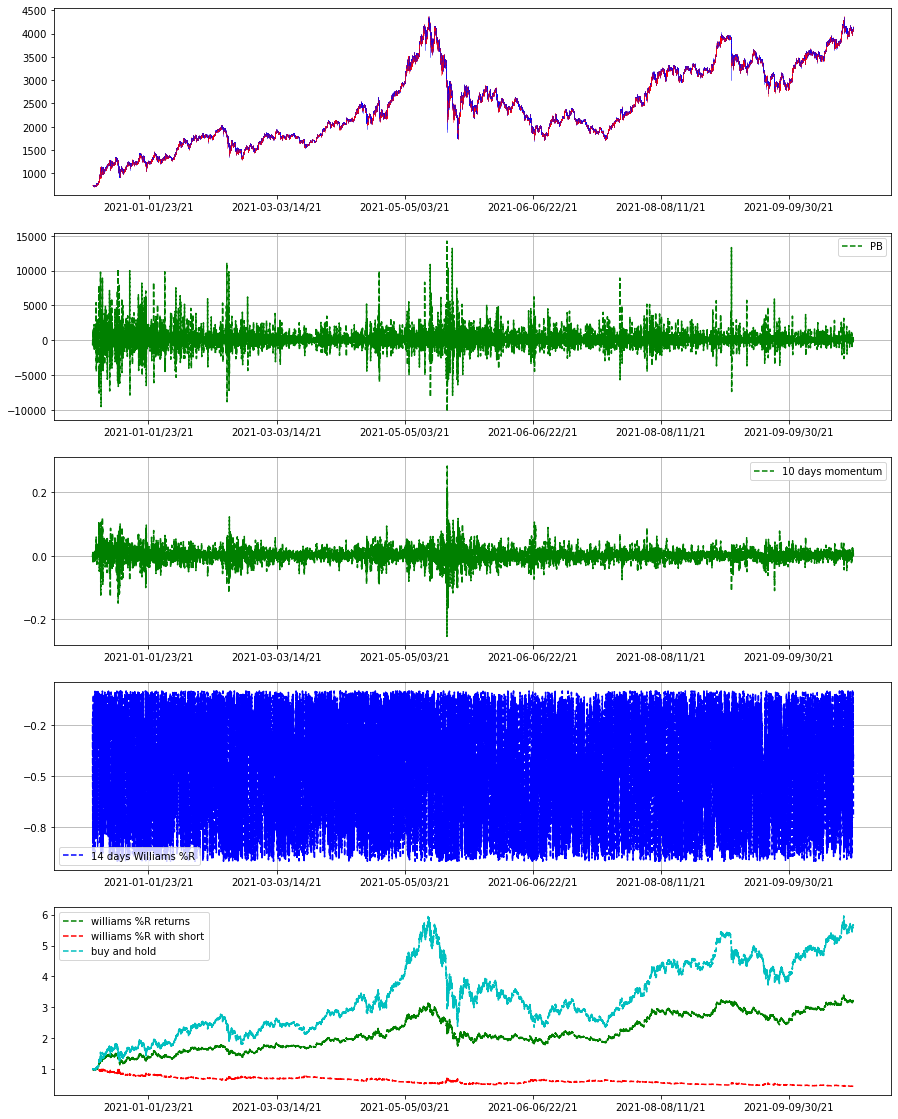

In [14]:
# let's see how the data looks like
ohlc = sample[['number', 'open', 'high', 'low', 'close']].copy()

plt.figure(figsize=(15, 20))
p1 = plt.subplot(5, 1, 1)
candlestick_ohlc(p1, ohlc.values, width=0.06, colorup='red', colordown='blue')
p1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%D'))

p2 = plt.subplot(5, 1, 2)
p2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%D'))
plt.plot(sample.number, sample.PB, 'g--', label='PB')
#plt.yticks([-20000, 0., 20000])
plt.grid()
plt.legend(loc='best')

p3 = plt.subplot(5, 1, 3)
p3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%D'))
plt.plot(sample.number, sample.momentum, 'g--', label='10 days momentum')
plt.yticks([-0.2, 0., 0.2])
plt.grid()
plt.legend(loc='best')

p4 = plt.subplot(5, 1, 4)
p4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%D'))
plt.plot(sample.number, sample.WilliamsPR, 'b--', label='14 days Williams %R')
plt.yticks([-0.2, -0.5, -0.8])
plt.grid()
plt.legend(loc='best')

p5 = plt.subplot(5, 1, 5)
p5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%D'))
plt.plot(book.number, book.acc_rtn, 'g--', label='williams %R returns')
plt.plot(book_short.number, book_short.acc_rtn, 'r--', label="williams %R with short")
plt.plot(sample.number, sample.acc_rtn, 'c--', label="buy and hold")
plt.legend(loc='best')
plt.show()